# 04a - Noisy Latent Dimension Sweep

Train the same latent autoencoder/propagator workflow on one selected dataset, defaulting to the noisy network set. First inspect a 2D latent model, then sweep latent dimensions `1, 2, 4, 6, 8, 10` and compare rollout p-ratio R2 across horizons.


## Setup


In [1]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lss.latent.capacity import build_capacity_specs, run_capacity_sweep
from lss.latent.experiment import find_project_root, rollout_curve_summary, seed_everything
from lss.latent.simulation import pearson_r, r2_score
from lss.utils import resolve_device

plt.rcParams['figure.dpi'] = 120


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

`selected_dataset` can be changed to another key in `dataset_specs`, but this notebook defaults to `noizy` as requested. Set `force_training=True` only when you want to retrain models that already exist in the output directory.


In [ ]:
project_root = find_project_root()
seed = random.SystemRandom().randrange(1, 2**31)
seed_everything(seed)
print('run seed:', seed)

selected_dataset = 'noizy'
latent_dims = [1, 2, 4, 6, 8, 10]

# Keep this at 1 for a quick sweep. Increase to 2-3 only if you want error bars.
sweep_repeats = 1
force_training = True

dataset_specs = {
    'reid': {
        'label': 'Reid',
        'path': '../../data/new_reid_combined.pt',
        'train_count': 10,
        'val_count': 10,
    },
    'depablo': {
        'label': 'dePablo',
        'path': '../../data/2340_dePablo_networks_OOL_undirected.pt',
        'train_count': 30,
        'val_count': 25,
    },
    'depablo-10k-mix-temp': {
        'label': 'dePablo 10k mixed temperature',
        'path': 'data/depablo-10k-mix-temp.pt',
        'train_count': 80,
        'val_count': 50,
    },
    'noizy': {
        'label': 'Noisy rand OOL',
         'path': 'data/200_rand_pruned_OOL_bidirect_val1057.pt',
        'train_count': 50,
        'val_count': 20,
    },
}

cfg = {
    'dataset_name': selected_dataset,
    'split_seed': seed,
    'split_stratify_temperature': selected_dataset == 'depablo-10k-mix-temp',
    'min_train_p_ratio': None,
    'device': 'auto',
    'pos_dim': 2,
    'batch_graphs': 4,
    'frame_skip': 1,
    'train_frame_start_order': 0,
    'latent_dim': 2,
    'latent_tokens': 16,
    'hidden_size': 64,
    'edge_feature_dim': 8,
    'ae_max_train_frames_per_sim': 100,
    'dyn_max_train_transitions_per_sim': 100,
    'ae_target_mode': 'delta',
    'node_feature_mode': 'delta',
    'ae_coordinate_weights': [1.0, 2.0],
    'ae_max_epochs': 180,
    'ae_patience': 5,
    'ae_lr': 1e-4,
    'ae_weight_decay': 1e-5,
    'dyn_max_epochs': 180,
    'dyn_patience': 5,
    'dyn_lr': 1e-4,
    'dyn_weight_decay': 1e-5,
    'propagator_loss': 'delta',
    'propagator_objective': 'one_step',
    'propagator_use_static_context': True,
    'graph_context_dim': 16,
    'propagator_context_include_temperature': False,
    'propagator_step_stride': 1,
    'initial_velocity': 'zero',
    'propagator_model': None,
    'early_stop_min_delta': 1e-5,
    'rollout_steps_grid': [10, 20, 50, 100, 150, 300],
    'temperature_pratio_window': 'full',
    'output_root': str(project_root / 'notebooks' / 'results' / 'noisy_latent_dim_sweep'),
}

device = resolve_device(cfg['device'])
run_dir = Path(cfg['output_root']) / selected_dataset
run_dir.mkdir(parents=True, exist_ok=True)
print('dataset:', selected_dataset)
print('device:', device)
print('output:', run_dir)


run seed: 145908353
dataset: noizy
device: cuda
output: /home/alexz/Documents/course_project/notebooks/results/noisy_latent_dim_sweep/noizy


## Train Or Load Dimension Sweep

This cell trains all requested latent dimensions or loads cached models from `run_dir / models`. The saved tables are written to `run_dir / exports`.


In [3]:
specs = build_capacity_specs(
    [selected_dataset],
    dataset_specs,
    cfg,
    latent_dims=latent_dims,
    train_counts=[dataset_specs[selected_dataset]['train_count']],
    train_frame_counts=[cfg['ae_max_train_frames_per_sim']],
    target_modes=[cfg['ae_target_mode']],
    repeats=sweep_repeats,
    seed=seed,
)

tables = run_capacity_sweep(
    specs,
    cfg,
    device=device,
    output_dir=run_dir,
    force_training=force_training,
    collect_initial_latents=True,
)

summary_df = tables['summary']
rollout_stats_df = tables['rollout_stats']
rollout_raw_df = tables['rollout_raw']
latent_raw_df = tables['latent_raw']
display(summary_df.sort_values(['latent_dim', 'repeat_idx']).round(4))


[1/6] noizy_delta_cv01_nets050_frames080_ctx016_rep01.pt

=== Noisy rand OOL CV1 delta ===
                              source                                                                              path  total  train  val  test
200_rand_pruned_OOL_bidirect_val1057 /home/alexz/Documents/course_project/data/200_rand_pruned_OOL_bidirect_val1057.pt    200     50   20   130
autoencoder
ae 0001 train=0.723298 val=0.676796 stale=0
ae 0002 train=0.673487 val=0.674033 stale=0
ae 0003 train=0.664303 val=0.656911 stale=0
ae 0004 train=0.664689 val=0.65323 stale=0
ae 0007 train=0.656103 val=0.653186 stale=0
ae 0010 train=0.654441 val=0.660576 stale=3
latent propagator: objective=one_step step_stride=1 train_rows=4000 val_rows=1600
propagator 0001 train=0.78547 val=0.290699 stale=0
rollout eval split=train: 6 horizons up to 300
rollout eval split=val: 6 horizons up to 300
rollout eval split=test: 6 horizons up to 300
[2/6] noizy_delta_cv02_nets050_frames080_ctx016_rep01.pt

=== Noisy rand OO

,dataset,dataset_name,dataset_label,target_mode,repeat_idx,model_seed,latent_dim,train_networks,train_frames_per_network,summary_rollout_step,test_rollout_final_pos_mse,test_rollout_position_r2,test_rollout_p_ratio_r2,ae_best_val_mse_norm,dyn_best_val_dz_mse_norm,model_path
0,Noisy rand OOL CV1 delta,noizy,Noisy rand OOL,delta,1,152195548,1,50,80,300,0.0147,0.0,-2.2826,0.6532,0.2907,/home/alexz/Documents/course_project/notebooks...
1,Noisy rand OOL CV2 delta,noizy,Noisy rand OOL,delta,1,152196557,2,50,80,300,2.8100,0.0,-0.0987,0.6277,0.9914,/home/alexz/Documents/course_project/notebooks...
2,Noisy rand OOL CV4 delta,noizy,Noisy rand OOL,delta,1,152198575,4,50,80,300,0.0642,0.0,-0.8511,0.6720,0.3847,/home/alexz/Documents/course_project/notebooks...
3,Noisy rand OOL CV6 delta,noizy,Noisy rand OOL,delta,1,152200593,6,50,80,300,0.0595,0.0,-0.8502,0.6646,0.3050,/home/alexz/Documents/course_project/notebooks...
4,Noisy rand OOL CV8 delta,noizy,Noisy rand OOL,delta,1,152202611,8,50,80,300,2.5842,0.0,-2.9556,0.6422,0.7781,/home/alexz/Documents/course_project/notebooks...
5,Noisy rand OOL CV10 delta,noizy,Noisy rand OOL,delta,1,152204629,10,50,80,300,232.9229,0.0,-0.5188,0.6380,0.6801,/home/alexz/Documents/course_project/notebooks...


## 2D Latent: Initial P-Ratio Readout

Fit a linear readout from the 2D initial latent to final p-ratio using validation networks only, then show held-out test predictions.


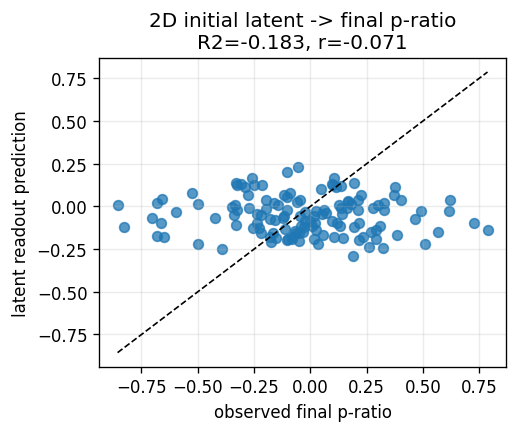

In [8]:
def fit_linear_readout(X_val, y_val):
    X_val = np.asarray(X_val, dtype=float)
    y_val = np.asarray(y_val, dtype=float)
    x_mean = X_val.mean(axis=0)
    x_std = X_val.std(axis=0) + 1e-12
    design = np.column_stack([np.ones(len(X_val)), (X_val - x_mean) / x_std])
    coef = np.linalg.lstsq(design, y_val, rcond=None)[0]
    return {'x_mean': x_mean, 'x_std': x_std, 'coef': coef}

def predict_linear_readout(model, X):
    X = np.asarray(X, dtype=float)
    design = np.column_stack([np.ones(len(X)), (X - model['x_mean']) / model['x_std']])
    return design @ model['coef']

latent_2d = latent_raw_df[
    latent_raw_df['latent_dim'].eq(2) & latent_raw_df['repeat_idx'].eq(1)
].copy()
z_cols = sorted(
    [col for col in latent_2d.columns if col.startswith('z') and latent_2d[col].notna().any()],
    key=lambda c: int(c[1:]),
)
if len(z_cols) != 2:
    raise ValueError(f'Expected exactly two populated z columns for the 2D run, got {z_cols}.')
val_2d = latent_2d[latent_2d['split'].eq('val')].replace([np.inf, -np.inf], np.nan).dropna(subset=[*z_cols, 'final_p_ratio'])
test_2d = latent_2d[latent_2d['split'].eq('test')].replace([np.inf, -np.inf], np.nan).dropna(subset=[*z_cols, 'final_p_ratio'])
if val_2d.empty or test_2d.empty:
    raise ValueError(
        f'Need non-empty val/test rows for the 2D latent readout; '
        f'got val={len(val_2d)}, test={len(test_2d)}. Rerun the sweep cell if needed.'
    )
model = fit_linear_readout(val_2d[z_cols], val_2d['final_p_ratio'])
test_pred = predict_linear_readout(model, test_2d[z_cols])

fig, ax = plt.subplots(figsize=(4.2, 3.5), constrained_layout=True)
ax.scatter(test_2d['final_p_ratio'], test_pred, s=34, alpha=0.75, color='tab:blue')
lo = min(test_2d['final_p_ratio'].min(), test_pred.min())
hi = max(test_2d['final_p_ratio'].max(), test_pred.max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
ax.set(
    title=f"2D initial latent -> final p-ratio\nR2={r2_score(test_2d['final_p_ratio'], test_pred):.3f}, r={pearson_r(test_2d['final_p_ratio'], test_pred):.3f}",
    xlabel='observed final p-ratio',
    ylabel='latent readout prediction',
)
ax.grid(alpha=0.25)
plt.show()


## What Each 2D Latent Coordinate Adds

First choose the single coordinate that best predicts final p-ratio on validation networks. Then remove that coordinate's linear effect and ask whether the other coordinate still explains residual final p-ratio.


primary coordinate: z1


,latent,val_r2,test_r2,test_r
1,z1,0.1956,-0.1840,-0.0715
0,z0,0.0010,-0.0129,0.0021


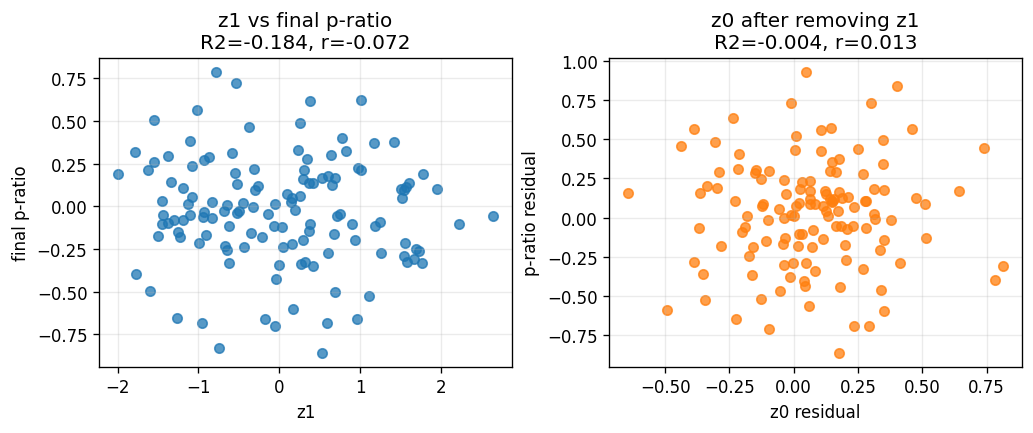

In [9]:
axis_rows = []
for z_col in z_cols:
    one_model = fit_linear_readout(val_2d[[z_col]], val_2d['final_p_ratio'])
    val_pred = predict_linear_readout(one_model, val_2d[[z_col]])
    test_axis_pred = predict_linear_readout(one_model, test_2d[[z_col]])
    axis_rows.append({
        'latent': z_col,
        'val_r2': r2_score(val_2d['final_p_ratio'], val_pred),
        'test_r2': r2_score(test_2d['final_p_ratio'], test_axis_pred),
        'test_r': pearson_r(test_2d['final_p_ratio'], test_axis_pred),
    })
axis_df = pd.DataFrame(axis_rows).sort_values('val_r2', ascending=False)
primary = axis_df.iloc[0]['latent']
secondary = [col for col in z_cols if col != primary][0]
print('primary coordinate:', primary)
display(axis_df.round(4))

primary_model = fit_linear_readout(val_2d[[primary]], val_2d['final_p_ratio'])
val_target_resid = val_2d['final_p_ratio'].to_numpy(float) - predict_linear_readout(primary_model, val_2d[[primary]])
test_target_resid = test_2d['final_p_ratio'].to_numpy(float) - predict_linear_readout(primary_model, test_2d[[primary]])
secondary_model = fit_linear_readout(val_2d[[primary]], val_2d[secondary])
val_secondary_resid = val_2d[secondary].to_numpy(float) - predict_linear_readout(secondary_model, val_2d[[primary]])
test_secondary_resid = test_2d[secondary].to_numpy(float) - predict_linear_readout(secondary_model, test_2d[[primary]])
resid_model = fit_linear_readout(val_secondary_resid.reshape(-1, 1), val_target_resid)
test_resid_pred = predict_linear_readout(resid_model, test_secondary_resid.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.5), constrained_layout=True)
axes[0].scatter(test_2d[primary], test_2d['final_p_ratio'], s=32, alpha=0.75)
axes[0].set(
    title=f'{primary} vs final p-ratio\nR2={axis_df.iloc[0].test_r2:.3f}, r={axis_df.iloc[0].test_r:.3f}',
    xlabel=primary,
    ylabel='final p-ratio',
)
axes[1].scatter(test_secondary_resid, test_target_resid, s=32, alpha=0.75, color='tab:orange')
axes[1].set(
    title=f'{secondary} after removing {primary}\nR2={r2_score(test_target_resid, test_resid_pred):.3f}, r={pearson_r(test_target_resid, test_resid_pred):.3f}',
    xlabel=f'{secondary} residual',
    ylabel='p-ratio residual',
)
for ax in axes:
    ax.grid(alpha=0.25)
plt.show()


## 2D Latent Rollout Example

At the requested 150-step horizon, compare predicted and true p-ratio for the 2D latent model.


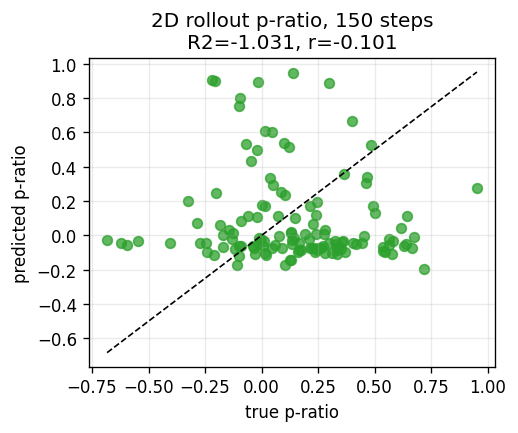

In [10]:
target_step = 150
available_steps = np.sort(rollout_raw_df['rollout_steps'].dropna().unique().astype(int))
plot_step = int(available_steps[np.argmin(np.abs(available_steps - target_step))])
rollout_2d = rollout_raw_df[
    rollout_raw_df['latent_dim'].eq(2)
    & rollout_raw_df['repeat_idx'].eq(1)
    & rollout_raw_df['split'].eq('test')
    & rollout_raw_df['rollout_steps'].eq(plot_step)
].copy()

fig, ax = plt.subplots(figsize=(4.2, 3.5), constrained_layout=True)
ax.scatter(rollout_2d['true_p_ratio'], rollout_2d['pred_p_ratio'], s=34, alpha=0.75, color='tab:green')
lo = min(rollout_2d['true_p_ratio'].min(), rollout_2d['pred_p_ratio'].min())
hi = max(rollout_2d['true_p_ratio'].max(), rollout_2d['pred_p_ratio'].max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
ax.set(
    title=f'2D rollout p-ratio, {plot_step} steps\nR2={r2_score(rollout_2d.true_p_ratio, rollout_2d.pred_p_ratio):.3f}, r={pearson_r(rollout_2d.true_p_ratio, rollout_2d.pred_p_ratio):.3f}',
    xlabel='true p-ratio',
    ylabel='predicted p-ratio',
)
ax.grid(alpha=0.25)
plt.show()


## Dimension Sweep: Rollout R2 Across Steps

Each line is a latent dimension. The metric is held-out rollout p-ratio R2 at each horizon.


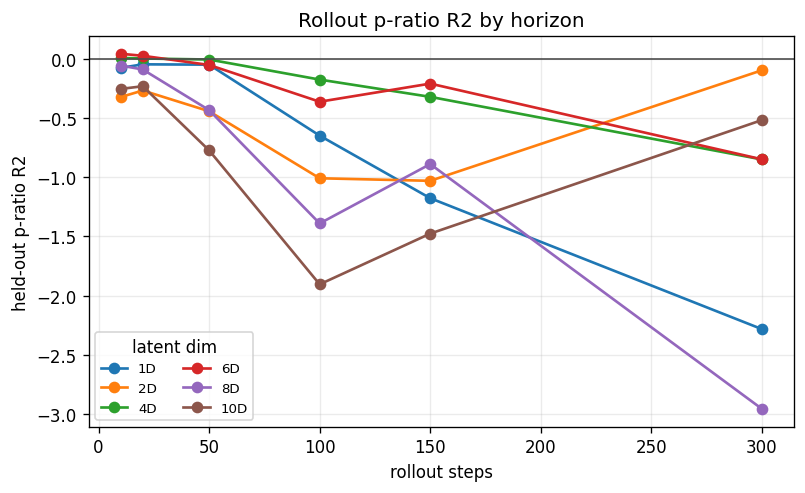

In [11]:
test_stats = rollout_stats_df[rollout_stats_df['split'].eq('test')].copy()
curve = (
    test_stats.groupby(['latent_dim', 'rollout_steps'], as_index=False)['p_ratio_r2']
    .mean()
    .sort_values(['latent_dim', 'rollout_steps'])
)

fig, ax = plt.subplots(figsize=(6.6, 4.0), constrained_layout=True)
for latent_dim, group in curve.groupby('latent_dim'):
    ax.plot(group['rollout_steps'], group['p_ratio_r2'], marker='o', lw=1.6, label=f'{int(latent_dim)}D')
ax.axhline(0, color='0.3', lw=1)
ax.set(
    title='Rollout p-ratio R2 by horizon',
    xlabel='rollout steps',
    ylabel='held-out p-ratio R2',
)
ax.grid(alpha=0.25)
ax.legend(title='latent dim', ncol=2, fontsize=8)
plt.show()


## Dimension Sweep: Best Repeat At 150 Steps

Use the horizon closest to 150 steps, then keep the best repeat for each latent dimension. With `sweep_repeats=1`, this is just the single run per dimension.


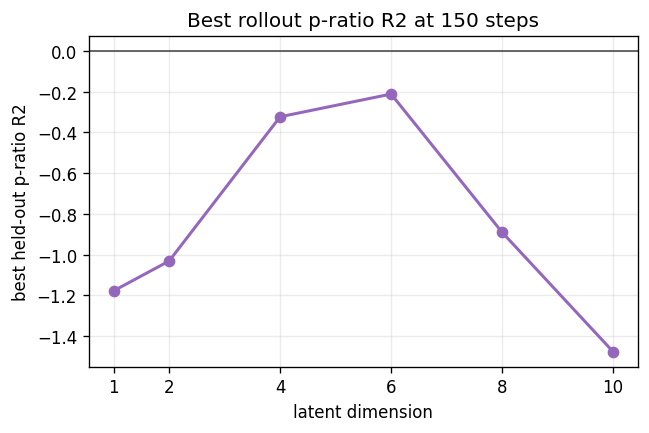

,latent_dim,repeat_idx,rollout_steps,p_ratio_r2,p_ratio_pearson,final_pos_mse
16,1,1,150,-1.1779,-0.1255,0.0017
34,2,1,150,-1.0313,-0.1005,0.0029
52,4,1,150,-0.3229,0.0955,0.0017
70,6,1,150,-0.2113,0.0539,0.0017
88,8,1,150,-0.8902,0.0718,0.0035
106,10,1,150,-1.4766,-0.0811,0.0064


In [12]:
target_step = 150
available_steps = np.sort(test_stats['rollout_steps'].dropna().unique().astype(int))
step_150 = int(available_steps[np.argmin(np.abs(available_steps - target_step))])
at_step = test_stats[test_stats['rollout_steps'].eq(step_150)].copy()
best_by_dim = (
    at_step.sort_values('p_ratio_r2', ascending=False)
    .drop_duplicates('latent_dim')
    .sort_values('latent_dim')
)

fig, ax = plt.subplots(figsize=(5.3, 3.5), constrained_layout=True)
ax.plot(best_by_dim['latent_dim'], best_by_dim['p_ratio_r2'], marker='o', lw=1.8, color='tab:purple')
ax.axhline(0, color='0.3', lw=1)
ax.set(
    title=f'Best rollout p-ratio R2 at {step_150} steps',
    xlabel='latent dimension',
    ylabel='best held-out p-ratio R2',
    xticks=latent_dims,
)
ax.grid(alpha=0.25)
plt.show()

display(best_by_dim[['latent_dim', 'repeat_idx', 'rollout_steps', 'p_ratio_r2', 'p_ratio_pearson', 'final_pos_mse']].round(4))
